/tmp/ipykernel_2194841/418385560.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


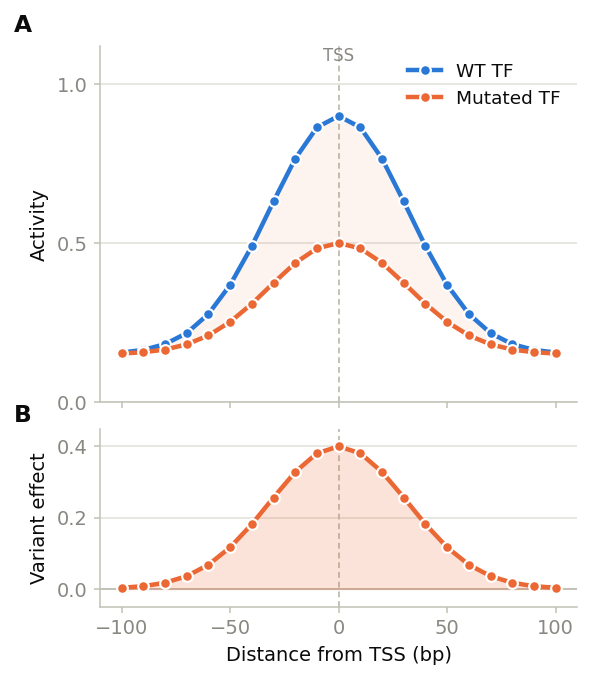

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Colorblind-safe categorical pair (adjacent slots, validated)
# ---------------------------------------------------------------
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_MUTED = "#0b0b0b", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
})

# Positions relative to the TSS
x = np.arange(-100, 101, 10)

def activity(x, amp):
    return 0.15 + amp * np.exp(-(x / 45) ** 2)

wt = activity(x, 0.75)     # WT TF activity
mut = activity(x, 0.35)    # Mutated TF activity
effect = wt - mut          # variant effect (loss of activity)

fig, ax = plt.subplots(
    2, 1, figsize=(4.4, 5.2), sharex=True, dpi=140,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.1},
)

###############################
# Panel A: activity
###############################
ax[0].axvline(0, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)
ax[0].text(0, 1.06, "TSS", ha="center", va="bottom", fontsize=8.5, color=INK_MUTED)

ax[0].fill_between(x, mut, wt, color=ORANGE, alpha=0.08, zorder=1)
ax[0].plot(x, wt, "-o", color=BLUE, lw=2.3, ms=5.5,
           mec="white", mew=1.1, zorder=3, label="WT TF")
ax[0].plot(x, mut, "-o", color=ORANGE, lw=2.3, ms=5.5,
           mec="white", mew=1.1, zorder=3, label="Mutated TF")

ax[0].set_ylabel("Activity")
ax[0].set_ylim(0, 1.12)
ax[0].set_yticks([0, 0.5, 1.0])
ax[0].legend(frameon=False, loc="upper right", fontsize=9.5, handlelength=1.8)

###############################
# Panel B: variant effect
###############################
ax[1].axvline(0, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)
ax[1].axhline(0, color=BASELINE, lw=1, zorder=1)
ax[1].fill_between(x, 0, effect, color=ORANGE, alpha=0.18, zorder=1)
ax[1].plot(x, effect, "-o", color=ORANGE, lw=2.3, ms=5.5,
           mec="white", mew=1.1, zorder=3)

ax[1].set_ylabel("Variant effect")
ax[1].set_xlabel("Distance from TSS (bp)")
ax[1].set_ylim(-0.05, 0.45)
ax[1].set_yticks([0, 0.2, 0.4])

###############################
# Shared styling
###############################
for label, a in zip("AB", ax):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_color(BASELINE)
    a.spines["bottom"].set_color(BASELINE)
    a.tick_params(direction="out", length=3, color=BASELINE)
    a.yaxis.grid(True, color=GRID, lw=0.8, zorder=0)
    a.set_axisbelow(True)
    a.text(-0.18, 1.04, label, transform=a.transAxes,
           fontsize=12, fontweight="bold", color=INK)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2194841/4250316043.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


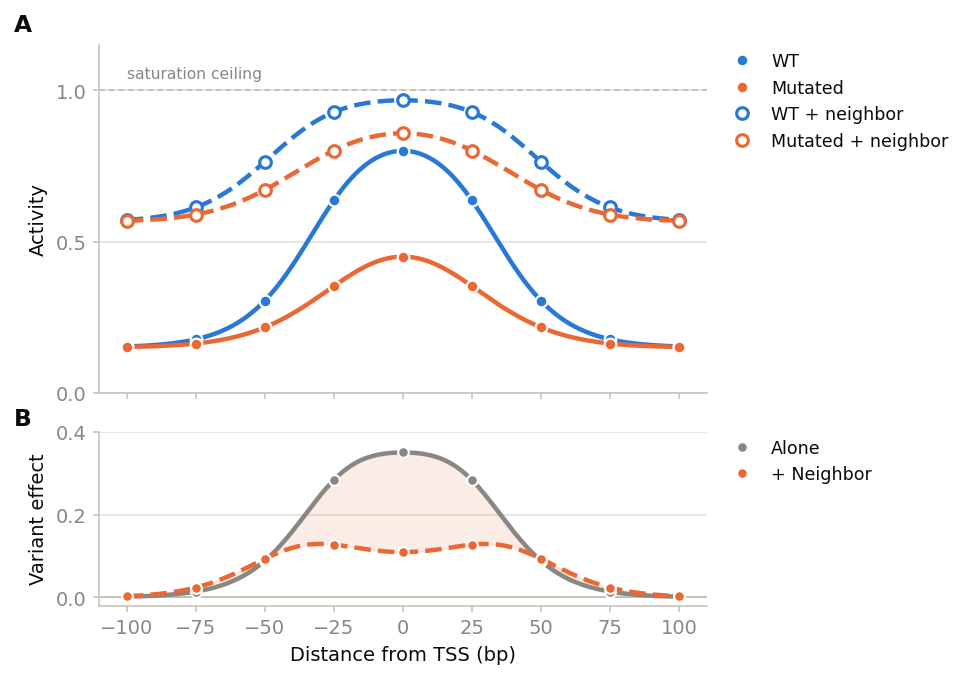

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# color = genotype, line style/marker fill = context (redundant
# encoding so the alone/+neighbor distinction isn't color-only)
# ---------------------------------------------------------------
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_MUTED = "#0b0b0b", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
})

# ---------------------------------------------------------------
# Model activity as a sigmoid of binding "drive" rather than
# clipping activity directly — saturation then falls out of the
# sigmoid's own curvature (flat near 0 and 1, steep in between)
# instead of an artificial hard ceiling.
# ---------------------------------------------------------------
def logit(p):
    return np.log(p / (1 - p))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def drive(x, baseline_activity, peak_activity):
    d0 = logit(baseline_activity)
    amp = logit(peak_activity) - d0
    return d0 + amp * np.exp(-(x / 45) ** 2)

NEIGHBOR_DELTA = 2.0  # drive contributed by the neighboring motif

x_smooth = np.linspace(-100, 100, 400)
x_tile = np.linspace(-100, 100, 9)  # tiled assay positions

D_wt = lambda x: drive(x, baseline_activity=0.15, peak_activity=0.80)
D_mut = lambda x: drive(x, baseline_activity=0.15, peak_activity=0.45)

def curves(x):
    wt = sigmoid(D_wt(x))
    mut = sigmoid(D_mut(x))
    wt_neighbor = sigmoid(D_wt(x) + NEIGHBOR_DELTA)
    mut_neighbor = sigmoid(D_mut(x) + NEIGHBOR_DELTA)
    return wt, mut, wt_neighbor, mut_neighbor

wt_s, mut_s, wt_neighbor_s, mut_neighbor_s = curves(x_smooth)
wt_t, mut_t, wt_neighbor_t, mut_neighbor_t = curves(x_tile)

effect_alone_s = wt_s - mut_s
effect_neighbor_s = wt_neighbor_s - mut_neighbor_s
effect_alone_t = wt_t - mut_t
effect_neighbor_t = wt_neighbor_t - mut_neighbor_t

fig, ax = plt.subplots(
    2, 1, figsize=(5.6, 5.2), sharex=True, dpi=140,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.15},
)

###############################
# Panel A: activity — smooth sigmoidal saturation, no clipping
###############################
ax[0].axhline(1.0, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)
ax[0].text(-100, 1.03, "saturation ceiling", ha="left", va="bottom",
           fontsize=8, color=INK_MUTED)

ax[0].plot(x_smooth, wt_s, "-", color=BLUE, lw=2.3, zorder=3)
ax[0].plot(x_tile, wt_t, "o", color=BLUE, ms=6, mec="white", mew=1.1,
           zorder=4, label="WT")
ax[0].plot(x_smooth, mut_s, "-", color=ORANGE, lw=2.3, zorder=3)
ax[0].plot(x_tile, mut_t, "o", color=ORANGE, ms=6, mec="white", mew=1.1,
           zorder=4, label="Mutated")
ax[0].plot(x_smooth, wt_neighbor_s, "--", color=BLUE, lw=2.3, zorder=2)
ax[0].plot(x_tile, wt_neighbor_t, "o", mfc="white", mec=BLUE, mew=1.6,
           ms=6, zorder=4, label="WT + neighbor")
ax[0].plot(x_smooth, mut_neighbor_s, "--", color=ORANGE, lw=2.3, zorder=2)
ax[0].plot(x_tile, mut_neighbor_t, "o", mfc="white", mec=ORANGE, mew=1.6,
           ms=6, zorder=4, label="Mutated + neighbor")

ax[0].set_ylabel("Activity")
ax[0].set_ylim(0, 1.15)
ax[0].set_yticks([0, 0.5, 1.0])
ax[0].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0),
             fontsize=9, handlelength=1.8, borderaxespad=0)

###############################
# Panel B: variant effect collapses near the TSS, where the
# +neighbor curves sit on the flat part of the sigmoid — not at
# the periphery, where neither curve is near saturation
###############################
ax[1].axhline(0, color=BASELINE, lw=1, zorder=1)
ax[1].fill_between(x_smooth, effect_neighbor_s, effect_alone_s,
                    color=ORANGE, alpha=0.12, zorder=1)
ax[1].plot(x_smooth, effect_alone_s, "-", color=INK_MUTED, lw=2.3, zorder=3)
ax[1].plot(x_tile, effect_alone_t, "o", color=INK_MUTED, ms=5.5,
           mec="white", mew=1.1, zorder=4, label="Alone")
ax[1].plot(x_smooth, effect_neighbor_s, "--", color=ORANGE, lw=2.3, zorder=3)
ax[1].plot(x_tile, effect_neighbor_t, "o", color=ORANGE, ms=5.5,
           mec="white", mew=1.1, zorder=4, label="+ Neighbor")

ax[1].set_ylabel("Variant effect")
ax[1].set_xlabel("Distance from TSS (bp)")
ax[1].set_ylim(-0.02, 0.4)
ax[1].set_yticks([0, 0.2, 0.4])
ax[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0),
             fontsize=9, handlelength=1.8, borderaxespad=0)

###############################
# Shared styling
###############################
for label, a in zip("AB", ax):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_color(BASELINE)
    a.spines["bottom"].set_color(BASELINE)
    a.tick_params(direction="out", length=3, color=BASELINE)
    a.yaxis.grid(True, color=GRID, lw=0.8, zorder=0)
    a.set_axisbelow(True)
    a.text(-0.14, 1.04, label, transform=a.transAxes,
           fontsize=12, fontweight="bold", color=INK)

plt.tight_layout()
plt.show()

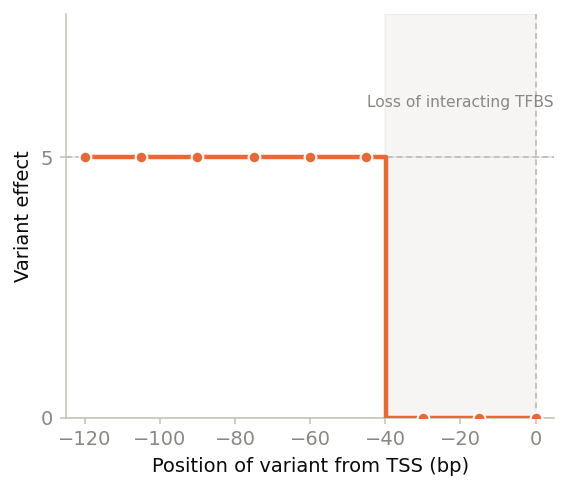

In [3]:
import numpy as np
import matplotlib.pyplot as plt

ORANGE = "#eb6834"
INK, INK_MUTED = "#0b0b0b", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
})

# ---------------------------------------------------------------
# Variant effect is constant at a distance from the TSS, then
# drops sharply to 0 within the TSS-proximal window where the
# interacting TFBS is lost.
# ---------------------------------------------------------------
PLATEAU = 5   # variant effect away from the TSS
ZONE = 40     # bp from TSS where the effect drops to 0

def effect_curve(x):
    return np.where(x <= -ZONE, PLATEAU, 0)

x_smooth = np.linspace(-120, 0, 400)
x_tile = np.linspace(-120, 0, 9)  # tiled assay positions

effect_s = effect_curve(x_smooth)
effect_t = effect_curve(x_tile)

fig, ax = plt.subplots(figsize=(4.2, 3.6), dpi=140)

ax.axvspan(-ZONE, 0, color=BASELINE, alpha=0.15, zorder=0)
ax.text(-ZONE / 2, PLATEAU * 1.18, "Loss of interacting TFBS", ha="center",
        va="bottom", fontsize=8, color=INK_MUTED)
ax.axvline(0, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)
ax.axhline(PLATEAU, color=BASELINE, lw=1, ls=(0, (3, 2)), zorder=1)

ax.plot(x_smooth, effect_s, "-", color=ORANGE, lw=2.3, zorder=3,
        drawstyle="steps-post")
ax.plot(x_tile, effect_t, "o", color=ORANGE, ms=6, mec="white", mew=1.1, zorder=4)

ax.set_xlabel("Position of variant from TSS (bp)")
ax.set_ylabel("Variant effect")
ax.set_xlim(-125, 5)
ax.set_ylim(0, PLATEAU * 1.55)
ax.set_yticks([0, PLATEAU])
ax.set_yticklabels(["0", "5"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(direction="out", length=3, color=BASELINE)
ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()